# **Mestrado em Ciência de Dados - 2.º Ano**
**Aluno:** Miguel Loureiro | 2220134

**Instituição:** Universidade de Leiria e Oeste  

***Dissertação:*** Data Mining Aplicado à Transformação Digital de uma PME Portuguesa de E-commerce: Um Caso de Estudo Integrado

---

# **Notebook 9. Regras de Associação | Apriori - Análise Temporal (Últimos 12 Meses)**

*O presente notebook engloba o problema de regras de associação aplicado ao período transacional mais recente (últimos 12 meses) da empresa em estudo, permitindo a comparação entre os padrões atuais de compra conjunta com os padrões verificados no histórico completo (NB8).*

---

## **Contextualização do problema em estudo**

### **Problema de negócio**

Identificar padrões de compra conjunta recentes que contribuam para formular estratégias de marketing, incluindo-se a componente de cross-selling e criação de bundles, em consonância com o catálogo atual e ativo da empresa. Além disso, é avaliada a evolução dos padrões ao longo do tempo, sendo identificadas as regras de associação que persistiram, que emergiram e que descontinuaram relativamente à análise realizada tendo por base o período completo de análise (NB8).

### **Escolha da janela temporal de 12 meses**

A opção pela utilização de uma janela temporal de 12 meses, um ano, é sustentada por três critérios:

**1. Captura completa da sazonalidade:** A empresa opera num mercado caracterizado por um comportamento de compra cíclico, assente no setor de animais de estimação e agricultura. Este tipo de mercado engloba ciclos de consumo, tais como: primavera (reprodução de aves, papas e suplementos, sementeiras), verão (parasitas, atividade ao ar livre, colheitas abundantes), outono/inverno (muda de pena, rações reforçadas, atividade agrícola menos intensa, época natalícia e black friday). Desta forma, o ciclo anual completo assegura que o algoritmo Apriori capta todas as estações do ano, sem privilegiar determinados períodos em detrimento de outros.

**2. Refletir o momento atual da empresa:** O conjunto de dados transacionais disponível abrange um período extenso, cobrindo cerca de 10 anos. Contudo, ao longo desse período, o portfólio de produtos sofreu diversas alterações, como por exemplo produtos descontinuados, novas marcas introduzidas, alterações de preços, novos produtos inseridos, alterações de nomenclatura e comunicação. A opção pela análise num período recente de 12 meses permite cobrir o catálogo ativo de produtos e as estratégias comerciais atuais, sem risco de enviesamento devido a produtos que foram excluídos do catálogo ou não estão ativos. Desta forma, mnimiza-se o risco de considerar padrões de comportamento de compra que já não se aplicam à base de clientes atual.

**3. Comparabilidade com o notebook anterior:** O NB8 recorre a todo o histórico transacional, representado por cerca de 10 anos e por 55.971 vendas. A comparação entre os resultados de ambos os notebooks permite classificar cada regra em três categorias distintas:

- **Persistentes** - regras que existem em ambos os períodos e refletem padrões estruturais do negócio.
- **Emergentes** - regras apenas presentes no período recente e que evidenciam novas oportunidades.
- **Descontinuadas** - regras apenas contempladas no histórico completo, demonstrando padrões de comportamento de compra antigos que já não se verificam.

### **Distinção face ao NB8**

|  | NB8 - Histórico Completo | **NB9 - Últimos 12 Meses (este notebook)** |
|---|---|---|
| **Período** | 13/02/2016 a 31/03/2026 (10 anos) | **01/04/2025 a 31/03/2026 (12 meses)** |
| **Universo** | 55.971 transações | **9.363 transações** |
| **Pergunta** | *"Que produtos foram comprados em conjunto no histórico completo?"* | *"Que produtos são comprados em conjunto atualmente (últimos 12 meses)?"* |
| **Aplicação** | Compreender padrões estruturais e de longo prazo | Definir estratégias de cross-sell e criação de bundles acionáveis no curto prazo |

### **Algoritmo aplicado**

O algoritmo a aplicar neste notebook consiste no Apriori, igualmente utilizado no NB8. Os parâmetros a utilizar são idênticos ao notebook anterior de forma a viabilizar uma comparação direta dos resultados:

| Parâmetro | Valor |
|---|---|
| `min_support` | 0,001
| `min_confidence` | 0,10
| `min_lift` | 2,0
| `min_length`, `max_length` | 2

### **Boas práticas adotadas**

- **Utilização de parâmetros idênticos ao NB8**, sendo essencial para a realização de análise temporal comparativa.
- **Filtragem temporal aplicada ao `df_linhas`**, assegurando que a análise é concretizada sobre transações efetivamente realizadas no período em análise.
- **Reconstrução das regras identificadas no histórico completo dentro do notebook**, garantindo que os dois conjuntos de regras (histórico completo + 12 meses) são desenvolvidos com o mesmo pipeline de pré-processamento.
- **Identificação das regras por par ordenado** (LHS → RHS), preservando a direccionalidade das regras na fase de comparação.

---

## **Estrutura do notebook**

1. Instalação e importação de bibliotecas
2. Carregamento e filtragem temporal dos dados
3. Construção das transações
4. Análise exploratória das transações (últimos 12 meses)
5. Determinação dos parâmetros do Apriori
6. Treino do modelo
7. Visualização e análise dos resultados
8. DataFrame com regras ordenadas
9. Comparação NB8 (histórico) vs NB9 (últimos 12 meses)
   - 9.1. Reconstrução das regras do NB8
   - 9.2. Construção dos conjuntos comparáveis
   - 9.3. Regras persistentes
   - 9.4. Regras emergentes
   - 9.5. Regras descontinuadas
   - 9.6. Visualização comparativa global
10. Síntese e implicações práticas

### **Outputs principais deste notebook**

- **Regras emergentes** identificadas nos últimos 12 meses
- **Regras persistentes** identificadas ao longo do histórico transacional da empresa
- **Regras descontinuadas** entre o histórico completo e os últimos 12 meses
- **Visualização comparativa** entre os três tipos de regras


## **1. Instalação e importação de bibliotecas**

Neste ponto, procede-se à instalação da biblioteca `apyori`, sendo essencial apenas na primeira execução. Além disso, são importadas as bibliotecas requeridas para esta componente analítica e que foram utilizadas no notebook anterior de forma a assegurar consistência do pipeline entre ambos os notebooks.

In [4]:
#Instalar a biblioteca apyori (necessária apenas na primeira execução)
!pip install apyori

In [5]:
#Importação das bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from apyori import apriori                   #algoritmo de mineração de regras de associação
from collections import Counter              #contagem de frequências de itens

## **2. Carregamento, normalização e filtragem temporal dos dados**

O carregamento dos dados é realizado a partir do dataframe ao nível da linha de produto (`df_linhas`).

Antes de aplicar o filtro temporal, procede-se à normalização da variável `Nome do Produto`, sendo um passo relevante para garantir a comparabilidade entre o histórico completo e os últimos 12 meses, dado que durante todo o período de atividade da empresa, o mesmo produto (identificado por `Ref Produto` não mutável) pode ter sido alvo de atualização de nomenclatura (ex.: substituição do separador `-` por `»`, diferenças em `700Gr.` vs `700Gr`). Este tipo de atualização impede o algoritmo Apriori de identificar regras como persistentes entre ambos os períodos em análise, mesmo que digam respeito ao mesmo conjunto de produtos. A solução para esta limitação passa por adotar, em cada `Ref Produto`, a nomenclatura mais recente observada no dataset, isto é, o nome atual do produto.

In [6]:
#Montar Drive e carregar dataset transacional completo
from google.colab import drive
drive.mount('/content/drive')

#Carregar o df_linhas exportado pelo NB1
df_full = pd.read_csv('/content/drive/MyDrive/df_linhas.csv')
df_full['Data'] = pd.to_datetime(df_full['Data'])

print(f'Dataset completo: {df_full.shape}')
print(f'Período total:    {df_full["Data"].min().date()} a {df_full["Data"].max().date()}')
print(f'Vendas únicas (histórico): {df_full["Ref Venda"].nunique()}')

Mounted at /content/drive
Dataset completo: (152976, 18)
Período total:    2016-02-13 a 2026-03-31
Vendas únicas (histórico): 55971


### **2.1. Normalização dos nomes de produto**

Conforme referido anteriormente, um produto apresenta uma `Ref Produto` estável ao longo do período de atividade da empresa, no entanto podem verificar-se alterações no `Nome do Produto`. Neste sentido, opta-se pela normalização aplicada ao `df_full` para que os próximos passos deste notebook, que incluem o filtro temporal, a construção de transações, o treino do algoritmo Apriori e a reconstrução das regras do histórico completo, sejam concretizados com os nomes normalizados de forma a garantir a comparabilidade direta das regras entre os dois períodos em análise.

In [7]:
#Normalização: para cada Ref Produto, aplicar o Nome do Produto mais recente, sendo a nomenclatura atual

#Construir o mapa Ref Produto -> Nome mais recente
#Ordena por Data e adota a última ocorrência de cada Ref Produto
mapa_normalizado = (
    df_full.sort_values('Data')
           .drop_duplicates('Ref Produto', keep='last')
           .set_index('Ref Produto')['Nome do Produto']
           .to_dict()
)

#Verificar quantos Ref Produto tinham variações no nome ao longo do histórico
variacoes = df_full.groupby('Ref Produto')['Nome do Produto'].nunique()
n_com_variacoes = (variacoes > 1).sum()
n_ref_produto = len(mapa_normalizado)

print(f'Total de Ref Produto únicos:                {n_ref_produto}')
print(f'Ref Produto com variações de nome:          {n_com_variacoes}')
print(f'Percentagem de produtos com variações:      {n_com_variacoes/n_ref_produto:.1%}')

#Aplicar o mapa normalizado ao df_full
df_full['Nome do Produto'] = df_full['Ref Produto'].map(mapa_normalizado)

print(f'\nNormalização aplicada - Nomes únicos após normalização: {df_full["Nome do Produto"].nunique()}')

Total de Ref Produto únicos:                5856
Ref Produto com variações de nome:          2145
Percentagem de produtos com variações:      36.6%

Normalização aplicada - Nomes únicos após normalização: 5724


Constata-se que existem 36,6% produtos com variações ao longo do tempo.

De seguida, é aplicado o filtro temporal que permite considerar apenas as transações concretizadas nos últimos 12 meses.

In [8]:
#Definir a janela temporal - últimos 12 meses
#data_ref = data máxima do dataset (1 dia antes da janela começar)
data_ref = df_full['Data'].max()

#data_inicio_12m = data_ref - 365 dias (janela de 12 meses)
data_inicio_12m = data_ref - pd.DateOffset(years=1)

print(f'Janela temporal: {data_inicio_12m.date()} a {data_ref.date()}')

#Filtrar transações da janela
df = df_full[
    (df_full['Data'] >= data_inicio_12m) &
    (df_full['Data'] <= data_ref)
].copy()

print(f'Dimensão (últimos 12 meses): {df.shape}')
print(f'Vendas únicas (12 meses):    {df["Ref Venda"].nunique()}')
print(f'Produtos únicos (12 meses):  {df["Nome do Produto"].nunique()}')

#Proporção do histórico
print(f'\nProporção do histórico (linhas): {len(df)/len(df_full):.1%}')

Janela temporal: 2025-03-31 a 2026-03-31
Dimensão (últimos 12 meses): (24443, 18)
Vendas únicas (12 meses):    9363
Produtos únicos (12 meses):  3014

Proporção do histórico (linhas): 16.0%


A data de referência, isto é, o último dia do dataset corresponde a 31 de março de 2026, levando a que o período temporal a considerar seja compreendido entre 31 de março de 2025 e 31 de março de 2026.

O novo conjunto de dados (últimos 12 meses) é composto por 9.363 vendas únicas e 3.014 produtos únicos, representando 16% do histórico transacional completo.

## **3. Construção das transações**

A construção das transações pressupõe que cada transação está associada a uma venda (`Ref Venda`), contemplando o conjunto dos produtos únicos comprados nessa mesma venda.

Neste processo é aplicada a mesma normalização do NB8 (`fillna + strip`) por questão de segurança, embora o subconjunto temporal seja menor.

In [9]:
#Tratar valores em falta no nome do produto
#Apesar de os nomes já terem sido normalizados anteriormente, esta operação permite assegurar consistência
#com o pipeline do NB8, aplicando a mesma normalização defensiva com fillna + strip
df['Nome do Produto'] = df['Nome do Produto'].fillna('Desconhecido').str.strip()

#Construir transações: para cada Ref Venda, lista dos produtos únicos comprados
transactions_series = df.groupby('Ref Venda')['Nome do Produto'].apply(lambda x: list(x.unique()))

print(f'Total de vendas (transações) nos últimos 12 meses: {len(transactions_series)}')
print(f'\nPrimeiras 5 transações:')
print(transactions_series.head())

Total de vendas (transações) nos últimos 12 meses: 9363

Primeiras 5 transações:
Ref Venda
46687                 [Friskies Cão VitaFit Active 4x18kg]
46688    [Canto Alegre - Mistura Diamantes Gould Profis...
46689    [Pet Cup - Papagaio Perfect Manutenção (10kg),...
46690    [Friskies Cão Vitafit Complete 2x18kg, Bogapro...
46691                   [Ownat Cão Classic Complet 2x20kg]
Name: Nome do Produto, dtype: object


Nas 5 primeiras vendas identificadas existem três rações para cão (Friskies Cão VitaFit Active 4x18kg, Friskies Cão Vitafit Complete 2x18kg, Ownat Cão Classic Complet 2x20kg) e 2 misturas para aves (Canto Alegre - Mistura Diamantes Gould Profissional 20kg, Pet Cup - Papagaio Perfect Manutenção 10kg), demonstrando a relevância do setor de animais de estimação na atividade global da empresa. Além disso, constata-se que existem transações (Ref Venda 46688, 46689, 46690) compostas por mais do que um produto.

De seguida, o conjunto de transações é convertido para uma lista, identificando a transação, o número de produtos e a lista de produtos de cada transação, sendo o formato requerido para os próximos passos. A validação da conversão é feita através da visualização das três primeiras transações, permitindo verificar se a conversão foi feita adequadamente e permitindo passar à análise exploratória das transações.

In [10]:
#Converter para lista de listas (formato apyori)
transactions = transactions_series.tolist()

#Confirmar a estrutura através de exemplos
print(f'Exemplo das primeiras 3 transações:')
for i, t in enumerate(transactions[:3], 1):
    print(f'  Transação {i} ({len(t)} produto(s)): {t}')

Exemplo das primeiras 3 transações:
  Transação 1 (1 produto(s)): ['Friskies Cão VitaFit Active 4x18kg']
  Transação 2 (3 produto(s)): ['Canto Alegre - Mistura Diamantes Gould Profissional (20kg)', 'Canto Alegre - Mistura Exóticos Profissional (20kg)', 'Deli Nature - Alpista Simples (20kg)']
  Transação 3 (2 produto(s)): ['Pet Cup - Papagaio Perfect Manutenção (10kg)', 'Pet Cup - Mistura Psitacideos Profissional (20Kg)']


## **4. Análise exploratória das transações (últimos 12 meses)**

Antes de iniciar a configuração e treino do algoritmo Apriori, é relevante compreender a estrutura das transações associadas aos últimos 12 meses através de uma análise exploratória. Este tipo de análise contribui para averiguar se os parâmetros escolhidos no NB8 continuam adequados à janela de 12 meses, uma vez que a última apresenta um número substancialmente inferior de transações e de produtos únicos.

In [11]:
#Distribuição do número de produtos por transação
#Comparação implícita com NB8, sendo expectável uma distribuição semelhante pela mesma natureza do negócio
n_produtos_por_transacao = pd.Series([len(t) for t in transactions])

print('Distribuição do número de produtos por transação:')
print(n_produtos_por_transacao.value_counts().sort_index().head(15).rename_axis('Produtos'))
print(f'\nMédia de produtos por transação: {n_produtos_por_transacao.mean():.2f}')
print(f'Máximo de produtos numa transação: {n_produtos_por_transacao.max()}')

#Transações multi-produto vs single-produto
n_multi = (n_produtos_por_transacao >= 2).sum()
n_single = (n_produtos_por_transacao == 1).sum()
print(f'\nTransações com 2+ produtos (multi-produto): {n_multi} ({n_multi/len(transactions):.1%})')
print(f'Transações com 1 produto (single-produto):  {n_single} ({n_single/len(transactions):.1%})')

Distribuição do número de produtos por transação:
Produtos
1     3728
2     2045
3     1388
4      839
5      551
6      331
7      173
8      106
9       71
10      43
11      30
12      23
13       9
14       9
15       2
Name: count, dtype: int64

Média de produtos por transação: 2.61
Máximo de produtos numa transação: 37

Transações com 2+ produtos (multi-produto): 5635 (60.2%)
Transações com 1 produto (single-produto):  3728 (39.8%)


In [12]:
#Top 20 produtos mais frequentes nas transações dos últimos 12 meses
#Mesma metodologia do NB8, facilitando a comparação visual entre os dois períodos
todos_produtos = [p for transacao in transactions for p in transacao]
freq_produtos = Counter(todos_produtos)
freq_df = pd.DataFrame(freq_produtos.items(), columns=['Nome do Produto', 'Frequência']).sort_values('Frequência', ascending=False)
freq_df['Support'] = (freq_df['Frequência'] / len(transactions)).round(4)

print(f'Total de produtos únicos no catálogo dos últimos 12 meses: {len(freq_df)}')
print(f'\nTop 20 produtos mais frequentes:')
print(freq_df.head(20).to_string(index=False))

Total de produtos únicos no catálogo dos últimos 12 meses: 3014

Top 20 produtos mais frequentes:
                                                                Nome do Produto  Frequência  Support
                                   Versele-Laga - Feno Nature Timothy Hay (1kg)         223   0.0238
         FELIX Fantastic Seleção de Favoritos em Gelatina - Jumbo Pack 44x85Gr.         191   0.0204
                              Pet Cup - Mistura Psitacideos Profissional (20Kg)         163   0.0174
 GOURMET GOLD Mousse para Gato - Coelho, Vaca, Vitela e Borrego (Pack 24x85Gr.)         143   0.0153
                                                           Grit + Coral » 2.5kg         142   0.0152
                              Pet Cup - Mistura Canários Mosaico Premium (20kg)         140   0.0150
GOURMET GOLD Tartelette para Gato - Frango, Vaca, Atum e Salmão (Pack 24x85Gr.)         139   0.0148
                                                 Pet Cup - Fonio Paddy (850Gr.)         133   

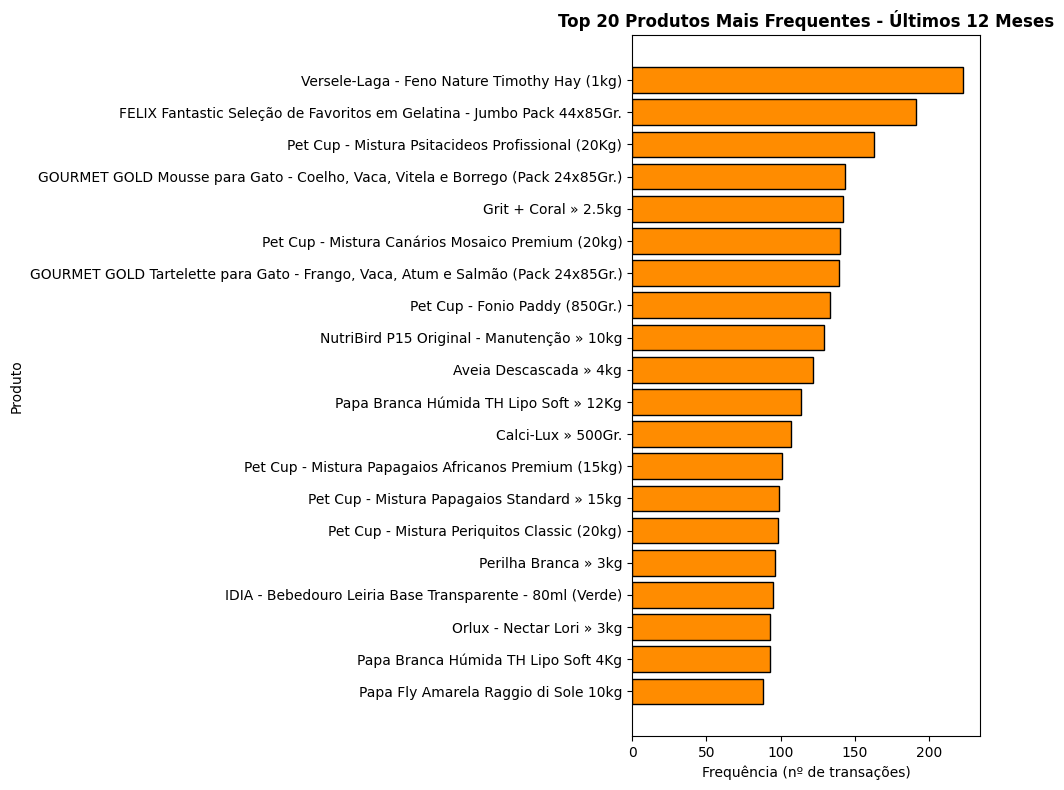

In [13]:
#Visualização: Top 20 produtos mais frequentes nos últimos 12 meses
plt.figure(figsize=(10, 8))

#Inverter a ordem para que o produto com maior frequência apareça no topo
top20 = freq_df.head(20).iloc[::-1]
plt.barh(top20['Nome do Produto'], top20['Frequência'], color='darkorange', edgecolor='black')

plt.title('Top 20 Produtos Mais Frequentes - Últimos 12 Meses', fontweight='bold')
plt.xlabel('Frequência (nº de transações)')
plt.ylabel('Produto')
plt.tight_layout()
plt.show()

Os resultados demonstram uma tendência clara para transações multi-produto, ou seja, compostas por mais do que 1 produto, estando representadas por 60,2% da totalidade das transações. Constata-se ainda uma média de 2,61 produtos por transação e um máximo de 37 produtos numa única transação. Desta forma, os resultados são semelhantes aos obtidos no notebook anterior, no qual se obteve uma média de 2,73 produtos por transação e 61,6% de transações multi-produto.

A análise dos 20 produtos que constam com maior frequência nas transações realizadas nos últimos 12 meses evidencia duas alterações substanciais em relação ao histórico transacional completo:

- **1. Pet Cup consolidou-se como marca dominante no segmento de aves**, destacando-se a existência de 8 dos 20 produtos associados a esta marca. Estes produtos correspondem a misturas para diversos espécies de aves e o seu posicionamento no top 20 representa um sinal claro de evolução estratégica do catálogo.
- **2. Alimentação húmida para gato em crescimento** com a existência de três produtos (2 da gama GOURMET GOLD e 1 da gama FELIX), destacando-se inclusivamente o FELIX Fantastic Seleção de Favoritos em Gelatina - Jumbo Pack 44x85Gr em 2º lugar do top com ocorrência em 191 transações.

O dataset dos últimos 12 meses é composto por 9.363 transações, levando a que a escolha do parâmetro `min_support = 0,001` esteja associada a apenas cerca de 10 co-ocorrências mínimas em contraste com as cerca de 56 no histórico completo. Neste contexto, é mantido o mesmo limite de forma a assegurar a comparabilidade direta entre resultados, embora o critério seja menos restritivo nesta janela temporal mais pequena.

## **5. Determinação dos parâmetros do Apriori**

Conforme referido anteriormente, os parâmetros escolhidos são similares aos do NB8, dada a necessidade de realizar uma análise temporal comparativa. A alteração dos limites de qualquer parâmetro resultaria numa interpretação desajustada das regras persistentes, emergentes e descontinuadas a identificar.

In [14]:
#Número total de transações nos últimos 12 meses
n_transacoes = len(transactions)
print(f'Total de transações (últimos 12 meses): {n_transacoes}')

#Equivalência min_support → nº de transações nesta janela
min_ocorrencias = 10
min_support_calc = min_ocorrencias / n_transacoes
print(f'min_support (>= {min_ocorrencias} co-ocorrências): {min_support_calc:.4f}')

#Parâmetros finais iguais ao NB8 para garantir comparabilidade
MIN_SUPPORT    = 0.001    #frequência mínima da regra
MIN_CONFIDENCE = 0.10     #probabilidade condicional mínima
MIN_LIFT       = 2.0      #força mínima da associação face ao acaso
MIN_LENGTH     = 2        #pares de produtos
MAX_LENGTH     = 2        #limitar a pares

print(f'\nParâmetros definidos iguais ao NB8 para comparabilidade:')
print(f'  min_support    = {MIN_SUPPORT}')
print(f'  min_confidence = {MIN_CONFIDENCE}')
print(f'  min_lift       = {MIN_LIFT}')
print(f'  min_length     = {MIN_LENGTH}')
print(f'  max_length     = {MAX_LENGTH}')

Total de transações (últimos 12 meses): 9363
min_support (>= 10 co-ocorrências): 0.0011

Parâmetros definidos iguais ao NB8 para comparabilidade:
  min_support    = 0.001
  min_confidence = 0.1
  min_lift       = 2.0
  min_length     = 2
  max_length     = 2


## **6. Treino do modelo Apriori**

Definidos os parâmetros, procede-se à aplicação do algoritmo Apriori no conjunto de transações dos últimos 12 meses, sendo realizado o mesmo processo do notebook anterior.

In [15]:
#Treinar Apriori com os parâmetros definidos
rules = apriori(
    transactions = transactions,
    min_support   = MIN_SUPPORT,
    min_confidence= MIN_CONFIDENCE,
    min_lift      = MIN_LIFT,
    min_length    = MIN_LENGTH,
    max_length    = MAX_LENGTH
)

#Converter generator em list
results = list(rules)
print(f'Número de regras encontradas (últimos 12 meses): {len(results)}')

if len(results) == 0:
    print('\nSugestão: reduzir MIN_SUPPORT para 0.0005 ou MIN_LIFT para 1.5')

Número de regras encontradas (últimos 12 meses): 77


O treino do modelo resultou na identificação de 77 regras de associação nos últimos 12 meses de análise. Este resultado é substancialmente superior ao obtido no notebook anterior (27 regras), que contemplava o histórico completo de transações. A opção pela manutenção do parâmetro `min_support = 0,001` possibilita a identificação de um maior número de regras de associação, dado que são requeridas apenas 10 co-ocorrências mínimas em contraste com as cerca de 56 no histórico completo.

## **7. Visualização dos resultados**

De forma a validar as regras de associação identificadas, procede-se à análise da estrutura de uma regra, tal como realizado no NB8, e à listagem das primeiras regras encontradas.

In [16]:
#Estrutura da primeira regra (para referência)
if len(results) > 0:
    print('Estrutura da primeira regra encontrada:')
    print(results[0])

Estrutura da primeira regra encontrada:
RelationRecord(items=frozenset({'Versele-Laga - Feno Nature Timothy Hay (1kg)', 'Aparas Granuladas Pet Cup 20kg'}), support=0.0010680337498664959, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Aparas Granuladas Pet Cup 20kg'}), items_add=frozenset({'Versele-Laga - Feno Nature Timothy Hay (1kg)'}), confidence=0.2127659574468085, lift=8.933307890468468)])


In [17]:
#Listagem linear de todas as regras encontradas
for i, regra in enumerate(results, 1):
    items_base = list(regra.ordered_statistics[0].items_base)
    items_add  = list(regra.ordered_statistics[0].items_add)
    print(f'Regra {i}: {items_base[0]} -> {items_add[0]}')
    print(f'  Support:    {regra.support:.4f}  ({int(regra.support * n_transacoes)} transações)')
    print(f'  Confidence: {regra.ordered_statistics[0].confidence:.4f}  ({regra.ordered_statistics[0].confidence:.1%})')
    print(f'  Lift:       {regra.ordered_statistics[0].lift:.4f}')
    print('-' * 50)

Regra 1: Aparas Granuladas Pet Cup 20kg -> Versele-Laga - Feno Nature Timothy Hay (1kg)
  Support:    0.0011  (10 transações)
  Confidence: 0.2128  (21.3%)
  Lift:       8.9333
--------------------------------------------------
Regra 2: Art.207 - Tampa com Asa p/ Transp. Tino -> Art.235 - Transportadora Tino Economica
  Support:    0.0011  (10 transações)
  Confidence: 0.4545  (45.5%)
  Lift:       250.3476
--------------------------------------------------
Regra 3: Aveia Descascada » 4kg -> Canhamo p/Aves 3kg
  Support:    0.0018  (17 transações)
  Confidence: 0.1393  (13.9%)
  Lift:       19.1865
--------------------------------------------------
Regra 4: Canhamo p/Aves » 600Gr. -> Aveia Descascada » 4kg
  Support:    0.0012  (11 transações)
  Confidence: 0.2340  (23.4%)
  Lift:       17.9618
--------------------------------------------------
Regra 5: Canto Alegre - Perilha (800Gr) -> Aveia Descascada » 4kg
  Support:    0.0011  (10 transações)
  Confidence: 0.1887  (18.9%)
  Lift:  

## **8. DataFrame com regras ordenadas**

Listadas as 77 regras identificadas, é realizada a conversão das mesmas para dataframe e são ordenadas por Lift em ordem descendente.
Este processo é realizada de forma similar ao NB8, utilizando a mesma função `inspect` e as mesmas colunas, possibilitando o cruzamento direto entre os dois conjuntos na secção 9.

In [18]:
#Função para converter as regras num DataFrame organizado
def inspect(results):
    lhs         = [tuple(result[2][0][0])[0] for result in results]
    rhs         = [tuple(result[2][0][1])[0] for result in results]
    supports    = [result[1] for result in results]
    confidences = [result[2][0][2] for result in results]
    lifts       = [result[2][0][3] for result in results]
    return list(zip(lhs, rhs, supports, confidences, lifts))


if len(results) > 0:
    #Construir o DataFrame com as regras dos últimos 12 meses
    df_regras_12m = pd.DataFrame(
        inspect(results),
        columns=['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift']
    )

    #Calcular o suporte absoluto em número de transações
    df_regras_12m['Support_abs'] = (
        df_regras_12m['Support'] * n_transacoes
    ).round(0).astype(int)

    #Apresentar o número total de regras encontradas
    print(f'Total de regras (últimos 12 meses): {len(df_regras_12m)}')

    #Ordenar as regras por Lift, do valor mais elevado para o mais baixo
    df_regras_12m = df_regras_12m.sort_values(
        by='Lift',
        ascending=False
    ).reset_index(drop=True)

    #Exportar as regras de associação dos últimos 12 meses para CSV
    df_regras_12m.to_csv(
        "/content/drive/MyDrive/regras_associacao_12m.csv",
        index=False,
        encoding="utf-8-sig"
    )

    #Confirmar a exportação do ficheiro
    print("Regras de associação dos últimos 12 meses exportadas para:")
    print("/content/drive/MyDrive/regras_associacao_12m.csv")

else:
    #Informar caso não tenham sido encontradas regras
    print("Não foram encontradas regras de associação nos últimos 12 meses.")

Total de regras (últimos 12 meses): 77
Regras de associação dos últimos 12 meses exportadas para:
/content/drive/MyDrive/regras_associacao_12m.csv


In [19]:
#Ordenar pelo Lift (descendente) - força da associação
print('Regras ordenadas por Lift (descendente):')
print(df_regras_12m.nlargest(n=len(df_regras_12m), columns='Lift').to_string(index=False))

Regras ordenadas por Lift (descendente):
                                                                Left Hand Side                                                                 Right Hand Side  Support  Confidence       Lift  Support_abs
                             Royal Canin - Húmido Gato Sterilised Loaf (85Gr.)                        Royal Canin - Húmido Gato Sterilised Wet (Jelly) (85Gr.) 0.001068    1.000000 936.300000           10
                                                   Bubi Nature Gato Atum/Manga                                                  Bubi Nature Gato Frango/Ananás 0.001282    0.857143 668.785714           12
                                                   Bubi Nature Gato Atum/Manga                                                    Bubi Nature Gato Atum/Salmão 0.001068    0.714286 668.785714           10
                                   Petfield - Lata Wetfood Dog Chicken » 410Gr                           Petfield - Lata Wetfood Dog Meat & Veg

A análise às regras identificadas demonstra que a 1ª regra com maior Lift (936,30) corresponde a produtos de alimentação húmida para gatos com diferentes texturas (Royal Canin - Húmido Gato Sterilised Loaf (85Gr.) → Royal Canin - Húmido Gato Sterilised Wet (Jelly) (85Gr.)), enquanto a última das 77 regras identificadas com menor Lift (5,50) diz respeito a um par de produtos que resulta da combinação entre mistura para periquitos e comida húmida para gatos, demonstrando a existência de tutores com diferentes tipos de animais de estimação (Pet Cup - Mistura Periquitos Classic 20kg → FELIX Fantastic Seleção de Favoritos em Gelatina - Jumbo Pack 44x85Gr.).

Como seria expectável, um número significativo de regras identificadas está associado a produtos do segmento de aves, resultado da predominância deste segmento na atividade da empresa.

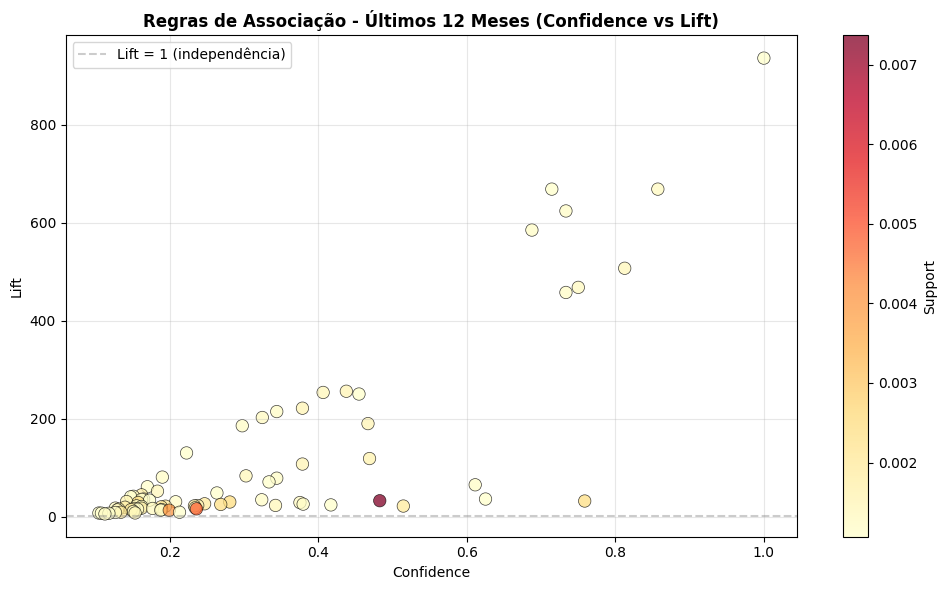

In [20]:
#Scatter plot Confidence vs Lift - visualização das regras (sem descrição textual para maior legibilidade)
plt.figure(figsize=(10, 6))
plt.scatter(
    df_regras_12m['Confidence'],
    df_regras_12m['Lift'],
    c=df_regras_12m['Support'],
    cmap='YlOrRd',
    s=80,
    alpha=0.75,
    edgecolors='black',
    linewidths=0.5
)
plt.colorbar(label='Support')
plt.axhline(1, color='gray', ls='--', alpha=0.4, label='Lift = 1 (independência)')
plt.title('Regras de Associação - Últimos 12 Meses (Confidence vs Lift)', fontweight='bold')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

A visualização apresentada através do Scatter Plot demonstra que existe um maior concentração das regras de associação com lift, support e confidence reduzidos, ao mesmo tempo que se verifica um número bastante reduzido (4) de regras com os valores dos parâmetros superiores (lift > 600, support > 0,005 e confidence > 0,6).

## **9. Comparação NB8 (Histórico completo) vs NB9 (Últimos 12 Meses)**

A presente secção é o ponto mais relevante deste notebook, na medida em que avalia como as regras de associação evoluíram entre o histórico completo (10 anos) e o período mais recente (últimos 12 meses). Esta comparação é realizada através da classificação de cada regra em três categorias distintas:

- **Regras persistentes** - presentes em ambos os períodos
- **Regras emergentes** - verificadas apenas no período recente
- **Regras descontinuadas** - existentes apenas no histórico completo

### **9.1. Reconstrução das regras do NB8 (histórico completo)**

A reconstrução das regras identificadas no notebook anterior possibilita uma comparação direta com as regras previamente identificadas neste notebook. Este processo de reconstrução assegura que a normalização aplicada através de`fillna + strip` é similar nos dois conjuntos de dados em utilização.

In [21]:
#Recalcular regras do histórico (mesmo procedimento do NB8, com nomes normalizados)
#Salientar que df_full foi normalizado previamente neste notebook, sendo que as Ref Produto utilizam o nome mais recente
#Esta abordagem assegura que regras persistentes entre os dois períodos não são ignoradas
#devido a ligeiras atualizações de nomenclatura ao longo do histórico de atividade da empresa
df_full['Nome do Produto'] = df_full['Nome do Produto'].fillna('Desconhecido').str.strip()
transacoes_hist = df_full.groupby('Ref Venda')['Nome do Produto'].apply(lambda x: list(x.unique())).tolist()

n_transacoes_hist = len(transacoes_hist)
print(f'Total de transações (histórico): {n_transacoes_hist}')

#Aplicar Apriori com os mesmos parâmetros do NB8 e NB9
rules_hist = apriori(
    transactions = transacoes_hist,
    min_support   = MIN_SUPPORT,
    min_confidence= MIN_CONFIDENCE,
    min_lift      = MIN_LIFT,
    min_length    = MIN_LENGTH,
    max_length    = MAX_LENGTH
)
results_hist = list(rules_hist)
print(f'Número de regras encontradas no histórico: {len(results_hist)}')

#Construir DataFrame das regras históricas (mesma estrutura que df_regras_12m)
df_regras_hist = pd.DataFrame(
    inspect(results_hist),
    columns=['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift']
)
df_regras_hist['Support_abs'] = (df_regras_hist['Support'] * n_transacoes_hist).round(0).astype(int)

Total de transações (histórico): 55971
Número de regras encontradas no histórico: 27


Tendo em conta a normalização aplicada aos nomes dos produtos, foram identificadas 27 regras de associação no histórico completo, tendo em consideração o histórico de 55.971 transações.

### **9.2. Construção dos conjuntos comparáveis**

A comparação das regras entre os dois períodos selecionados é possibilitada pela representação de cada regra por par ordenado de produtos. Neste contexto, A → B e B → A são tratadas como regras distintas pelo Apriori, apresentando Confidence diferente, pelo que o conjunto é construído sobre o par ordenado para preservar a direção da regra.

In [22]:
#Criar identificadores únicos para cada regra (par ordenado LHS → RHS)
df_regras_hist['Regra'] = df_regras_hist['Left Hand Side'] + ' -> ' + df_regras_hist['Right Hand Side']
df_regras_12m['Regra']  = df_regras_12m['Left Hand Side']  + ' -> ' + df_regras_12m['Right Hand Side']

#Conjuntos para operações de comparação
regras_hist = set(df_regras_hist['Regra'])
regras_12m  = set(df_regras_12m['Regra'])

#Operações de conjuntos para classificar cada regra
persistentes   = regras_hist & regras_12m       #em ambos
emergentes     = regras_12m - regras_hist       #só nos últimos 12 meses
descontinuadas = regras_hist - regras_12m       #só no histórico

print(f'Regras encontradas no histórico:    {len(regras_hist)}')
print(f'Regras encontradas nos 12 meses:    {len(regras_12m)}')
print()
print(f'Regras PERSISTENTES (em ambos):     {len(persistentes)}')
print(f'Regras EMERGENTES (só 12 meses):    {len(emergentes)}')
print(f'Regras DESCONTINUADAS (só hist):    {len(descontinuadas)}')

Regras encontradas no histórico:    27
Regras encontradas nos 12 meses:    77

Regras PERSISTENTES (em ambos):     16
Regras EMERGENTES (só 12 meses):    61
Regras DESCONTINUADAS (só hist):    11


Os resultados da comparação entre ambos os períodos demonstram a existência de:
- 16 regras persistentes
- 61 regras emergentes
- 11 regras descontinuadas

De seguida, cada uma das três classes de regras (persistentes, emergentes e descontinuadas) são analisadas com maior detalhe.

### **9.3. Regras persistentes - Resultado obtido: 16 regras**

A análise comparativa demonstrou que existem 16 regras do histórico completo que permanecem idênticas nas 77 regras dos últimos 12 meses.

In [23]:
#Construir tabela de regras persistentes com métricas dos dois períodos
if len(persistentes) > 0:
    df_persist = pd.merge(
        df_regras_hist[['Regra', 'Support', 'Confidence', 'Lift']].rename(
            columns={'Support': 'Sup_Hist', 'Confidence': 'Conf_Hist', 'Lift': 'Lift_Hist'}
        ),
        df_regras_12m[['Regra', 'Support', 'Confidence', 'Lift']].rename(
            columns={'Support': 'Sup_12m', 'Confidence': 'Conf_12m', 'Lift': 'Lift_12m'}
        ),
        on='Regra'
    )

    #Calcular variações (diferenças entre os 2 períodos)
    df_persist['Δ Support']    = (df_persist['Sup_12m'] - df_persist['Sup_Hist']).round(4)
    df_persist['Δ Confidence'] = (df_persist['Conf_12m'] - df_persist['Conf_Hist']).round(4)
    df_persist['Δ Lift']       = (df_persist['Lift_12m'] - df_persist['Lift_Hist']).round(2)

    print(df_persist.to_string(index=False))
else:
    print('Nenhuma regra persistente entre os dois períodos.')
    print('Todas as 27 regras do histórico desapareceram; todas as 77 regras dos 12 meses são novas.')

                                                                                                                                                            Regra  Sup_Hist  Conf_Hist  Lift_Hist  Sup_12m  Conf_12m   Lift_12m  Δ Support  Δ Confidence  Δ Lift
                                                                                                                   Aveia Descascada » 4kg -> Perilha Branca » 3kg  0.001394   0.128289  11.675594 0.001922  0.147541  14.389857     0.0005        0.0193    2.71
                                                                                                                          Calci-Lux » 500Gr. -> Ferti-Vit » 200Gr  0.001554   0.153169  19.308610 0.001495  0.130841  15.507157    -0.0001       -0.0223   -3.80
                                                                                       Deli Nature 20 - Serengeti (15kg) -> Deli Nature 22 - Amazonas Park (15kg)  0.001429   0.259740 104.589367 0.001388  0.183099  51.950064    -0

### **9.4. Regras emergentes - 61 regras**

Foram identificadas 61 regras novas nos últimos 12 meses, sendo que este tipo de regras está associado ao catálogo ativo, ao comportamento atual dos clientes e ao portfólio de marcas atualmente comercializadas. Estas características tornam este tipo de regras mais adequado nos processos de criação de bundles e de campanhas de cross-sell.

In [24]:
#Listar todas as regras emergentes - ordenadas por Lift descendente
if len(emergentes) > 0:
    df_emerg = df_regras_12m[df_regras_12m['Regra'].isin(emergentes)].copy()
    df_emerg = df_emerg[['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift', 'Support_abs']]
    print(f'Regras EMERGENTES ({len(df_emerg)}) - ordenadas por Lift:')
    print(df_emerg.nlargest(n=len(df_emerg), columns='Lift').to_string(index=False))
else:
    print('Não existem regras emergentes.')

Regras EMERGENTES (61) - ordenadas por Lift:
                                          Left Hand Side                                                                 Right Hand Side  Support  Confidence       Lift  Support_abs
       Royal Canin - Húmido Gato Sterilised Loaf (85Gr.)                        Royal Canin - Húmido Gato Sterilised Wet (Jelly) (85Gr.) 0.001068    1.000000 936.300000           10
                             Bubi Nature Gato Atum/Manga                                                  Bubi Nature Gato Frango/Ananás 0.001282    0.857143 668.785714           12
                             Bubi Nature Gato Atum/Manga                                                    Bubi Nature Gato Atum/Salmão 0.001068    0.714286 668.785714           10
             Petfield - Lata Wetfood Dog Chicken » 410Gr                           Petfield - Lata Wetfood Dog Meat & Vegetables » 410Gr 0.001175    0.733333 624.200000           11
               Petfield - Lata Wetfood Dog Be

### **9.5. Regras descontinuadas - 11 regras**

Existem 11 regras que provinham do histórico completo, mas que não se refletiram nos últimos 12 meses, sendo consequência, por exemplo, da reformulação e descontinuação efetiva dos produtos.

In [25]:
#Listar todas as regras descontinuadas - ordenadas por Lift no histórico
if len(descontinuadas) > 0:
    df_desc = df_regras_hist[df_regras_hist['Regra'].isin(descontinuadas)].copy()
    df_desc = df_desc[['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift', 'Support_abs']]
    print(f'Regras DESCONTINUADAS ({len(df_desc)}) - ordenadas por Lift no histórico:')
    print(df_desc.nlargest(n=len(df_desc), columns='Lift').to_string(index=False))
else:
    print('Não existem regras descontinuadas.')

Regras DESCONTINUADAS (11) - ordenadas por Lift no histórico:
                               Left Hand Side                              Right Hand Side  Support  Confidence       Lift  Support_abs
                          Curva Plástico 12mm       Tê de 12mm para Bebedouros Automáticos 0.001572    0.807339 231.731263           88
                       Torneira Passagem 12mm       Tê de 12mm para Bebedouros Automáticos 0.001126    0.567568 162.909356           63
       Ninho Plástico Grande c/ Grampo - 12cm                   Ninho Sisal Cosido Ø12x4cm 0.001001    0.162791  57.668089           56
                    Seresto Grande (70cm) Cão                   Seresto Pequeno (38cm) Cão 0.001840    0.217759  54.655552          103
                         Coleira Seresto Gato                   Seresto Pequeno (38cm) Cão 0.001036    0.207143  51.990999           58
Cubetto Wood - Madeira Natural Prensada (7kg) Versele-Laga - Feno Nature Timothy Hay (1kg) 0.001572    0.578947  35.107544

### **9.6. Visualização comparativa global**

Com o intuito de visualizar mais facilmente os três tipos de regras consoante os seus valores de Confidence vs Lift, apresenta-se um gráfico de dispersão com cores diferentes para cada tipo de regra (persistentes, emergentes e descontinuadas).

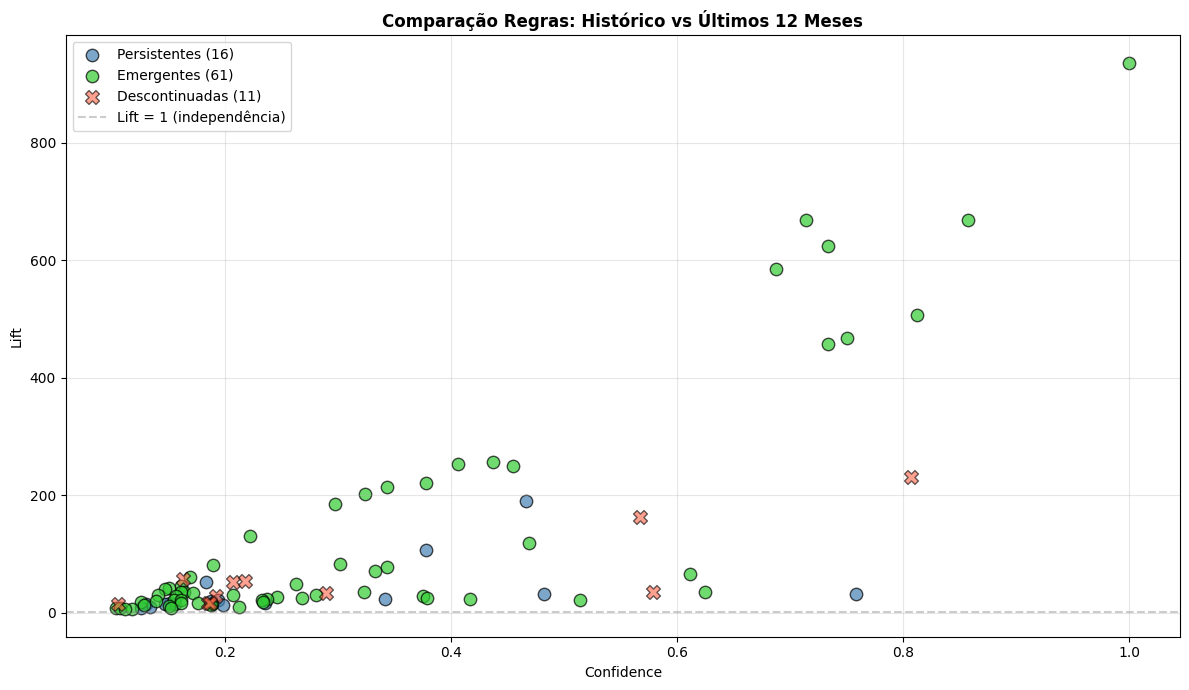

In [26]:
#Visualização comparativa dos três grupos de regras
fig, ax = plt.subplots(figsize=(12, 7))

#Regras Persistentes - usar os valores dos últimos 12 meses
if len(persistentes) > 0:
    p = df_regras_12m[df_regras_12m['Regra'].isin(persistentes)]
    ax.scatter(p['Confidence'], p['Lift'], s=80, c='steelblue', alpha=0.7,
               edgecolors='black', label=f'Persistentes ({len(p)})')

#Regras Emergentes (só 12 meses)
if len(emergentes) > 0:
    e = df_regras_12m[df_regras_12m['Regra'].isin(emergentes)]
    ax.scatter(e['Confidence'], e['Lift'], s=80, c='limegreen', alpha=0.7,
               edgecolors='black', label=f'Emergentes ({len(e)})')

#Regras Descontinuadas (só histórico) - marcador X para distinguir visualmente
if len(descontinuadas) > 0:
    d = df_regras_hist[df_regras_hist['Regra'].isin(descontinuadas)]
    ax.scatter(d['Confidence'], d['Lift'], s=100, c='tomato', alpha=0.6,
               edgecolors='black', marker='X', label=f'Descontinuadas ({len(d)})')

ax.set_title('Comparação Regras: Histórico vs Últimos 12 Meses', fontweight='bold')
ax.set_xlabel('Confidence')
ax.set_ylabel('Lift')
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.4, label='Lift = 1 (independência)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **10. Síntese e implicações práticas**

### **Resumo dos resultados obtidos**

| Indicador | Histórico (NB8) | Últimos 12 meses (NB9) |
|---|---|---|
| Período | 10 anos (fev 2016 – mar 2026) | 12 meses (mar 2025 – mar 2026) |
| Nº de Transações | 55.971 | 9.363 |
| Nº de Produtos únicos | 5.723 | 3.014 |
| Nº de Regras identificadas | 27 | 77 |
| Valor máximo de Lift | 231,7 | 936,3 |

### **Resultado da análise temporal**

- **16 regras persistentes** efetivamente mantidas ao longo do tempo
- **61 regras emergentes**, exclusivas dos últimos 12 meses
- **11 regras descontinuadas**, estando associadas a regras do histórico completo que desapareceram

A análise comparativa realizada entre os dois períodos em análise permite dividir as regras de associações em três classes essenciais para a definição da estratégia comercial da empresa:

**1. Regras persistentes** - Dizem respeito a combinações de produtos que permanecem associadas ao longo de todo o histórico transacional. Estas combinações são essenciais a ter em consideração para a criação de bundles e de promoções recorrentes no website, dado que a probabilidade de este padrão deixar de se verificar a curto prazo é bastante reduzida.

**2. Regras emergentes** - Estas regras são evidentes apenas no período mais recente e demonstram o catálogo ativo e o comportamento atual dos clientes. As combinações identificadas são compostas por novos produtos, modificações no comportamento de compra, ou dizem respeito a associações que ainda não atingiam o limite mínimo de suporte no histórico completo. Estes resultados constituem uma base essencial para criação de campanhas de cross-sell de curto prazo, podendo ser relevantes, inclusivamente, para promover produtos novos.

**3. Regras descontinuadas** - Regras existentes no histórico completo, mas que não transitaram para o período mais recente em análise. Estas regras podem ser compostas por produtos descontinuados, alterações no perfil de clientes ou adoção de estratégias de marketing distintas no passado. As regras identificadas não devem ser usadas atualmente, dado o risco de promover associações irrelevantes.